# Feature Importance

In this notebook, we analyze which features contribute the most to the Random Forest model's predictions.

Understanding feature importance helps explain the model's decision-making process and provides insights into the factors affecting second-hand car prices.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

In [2]:
df = pd.read_csv("../data/processed/carsight_clean.csv")

df.head()

,ilanBasligi,adres,il,fiyat(TRY),ilanID,ilanTarihi,marka,seri,model,kilometre(Km),...,boyaParcaDurumu,takasUygunluk,saticiTuru,aracVergisi(TRY),hasarGecmisi,orjinal_parça_sayısı,lokal_boyalı_parça_sayısı,boyalı_parça_sayısı,değişen_parça_sayısı,durumu_belirtilmemiş_parça_sayısı
0,2016 AUDİ A3 SPORTBACK 1.0 TFSI BOYASIZ/DEĞİŞE...,Aşağısoku Mh. Merkez,Bolu,1169000,27812680,07 Nisan 2025,Audi,A3,A3 Sportback 1.0 TFSI Dynamic,120000.0,...,Orjinal Sağ Arka Çamurluk Arka Kaput Sol Ar...,Takasa Uygun,NaN,NaN,NaN,13,0,0,0,0
1,2018 AUDİ A6 2.0 TDI QUATTRO SUNROOF MATRİX VA...,Güneşevler Mh. Altındağ,Ankara,2450000,28816234,07 Nisan 2025,Audi,A6,A6 Sedan 2.0 TDI Quattro,136000.0,...,Orjinal Arka Kaput Sağ Arka Kapı Sağ Ön Kap...,Takasa Uygun Değil,Galeriden,NaN,tutarı belirtilmemiş,8,0,4,1,0
2,Sahibinden Audi A4 Sedan 1.8 TFSI 2011 Model,Burmalı Mh. Merkez,Afyonkarahisar,750000,28781662,08 Nisan 2025,Audi,A4,A4 Sedan 1.8 TFSI,285000.0,...,Orjinal Tavan Sol Ön Kapı Motor Kaputu Ön ...,Takasa Uygun Değil,Sahibinden,2.013,75.000,5,2,6,0,0
3,2016 AUDI A3 AMBİENTE *CAM TAVAN LED XENON HIZ...,Ilıca Mh. Manavgat,Antalya,1195000,28731117,03 Nisan 2025,Audi,A3,A3 Sportback 1.6 TDI Ambiente,101000.0,...,Orjinal Sağ Arka Çamurluk Arka Kaput Sağ Ar...,Takasa Uygun,Galeriden,1.606,tutarı yok,11,1,0,1,0
4,Sahibinden Audi A3 Sportback 1.6 TDI S-Line 20...,Uğur Mumcu Mh. Yenimahalle,Ankara,822000,28393351,02 Nisan 2025,Audi,A3,A3 Sportback 1.6 TDI Attraction,212000.0,...,Orjinal Sağ Arka Çamurluk Arka Kaput Sol Ar...,NaN,NaN,NaN,tutarı belirtilmemiş,12,1,0,0,0


In [3]:
features = [
    "marka",
    "yıl",
    "kilometre(Km)",
    "vitesTipi",
    "yakitTuru",
    "kasaTipi"
]

X = df[features]
y = df["fiyat(TRY)"]

In [4]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [5]:
X.shape

(6674, 54)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=1,
    random_state=42
)

In [8]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of 

In [9]:
importance = model.feature_importances_

importance

array([1.86916472e-01, 1.79285213e-01, 5.04665125e-03, 4.94466796e-02,
       4.49831539e-02, 1.02739923e-01, 4.16660546e-02, 8.65139825e-05,
       5.08098075e-05, 1.06399705e-05, 1.92855056e-07, 1.95763498e-03,
       0.00000000e+00, 8.59801569e-04, 2.32347498e-04, 6.20108847e-06,
       2.01445463e-04, 1.86678879e-04, 1.15782645e-05, 5.38994762e-06,
       0.00000000e+00, 3.42745831e-05, 1.28700838e-04, 2.36284207e-02,
       1.38816845e-09, 6.96605208e-08, 1.85157025e-04, 2.75462523e-04,
       7.99985322e-02, 8.01220412e-04, 1.52817329e-01, 7.60515641e-05,
       4.11116883e-04, 7.33856190e-08, 4.95287122e-06, 3.44839010e-04,
       4.38473347e-06, 1.48300965e-03, 2.92454979e-03, 1.13294977e-03,
       3.55763764e-02, 3.03964212e-03, 7.26913786e-03, 4.64708503e-03,
       4.48813065e-04, 4.85845048e-03, 3.46904132e-02, 1.49486151e-04,
       4.86998516e-03, 1.11890396e-04, 1.52787646e-03, 4.67990685e-05,
       6.17537993e-03, 1.86441871e-02])

In [10]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance.head()

,Feature,Importance
0,yıl,0.186916
1,kilometre(Km),0.179285
2,marka_Aston Martin,0.005047
3,marka_Audi,0.049447
4,marka_BMW,0.044983


In [11]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
0,yıl,0.186916
1,kilometre(Km),0.179285
30,marka_Rolls-Royce,0.152817
5,marka_Bentley,0.102740
28,marka_Porsche,0.079999
3,marka_Audi,0.049447
4,marka_BMW,0.044983
6,marka_Chevrolet,0.041666
40,vitesTipi_Otomatik,0.035576
46,kasaTipi_Coupe,0.034690


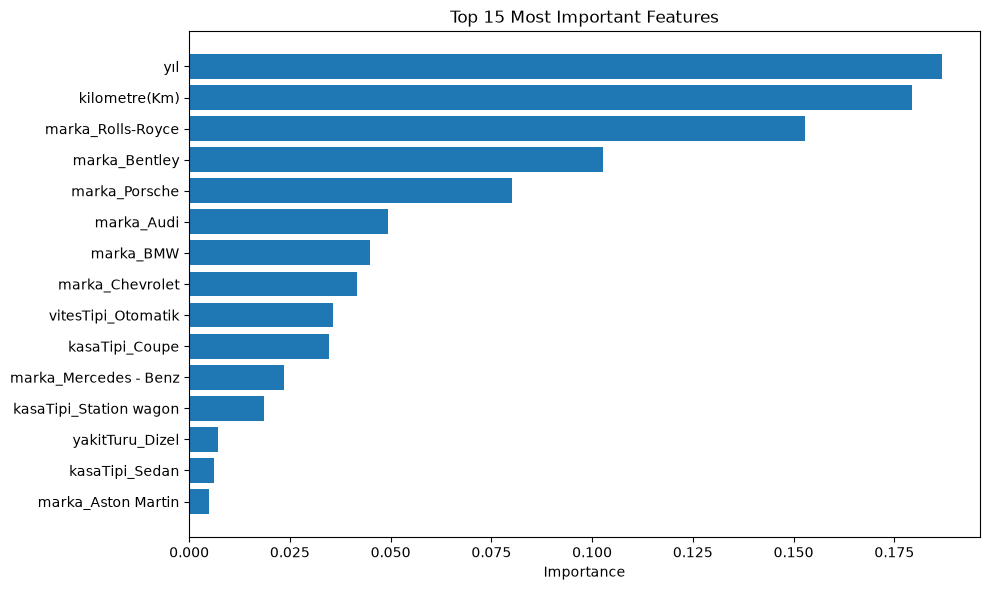

In [13]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:15],
    feature_importance["Importance"][:15]
)

plt.title("Top 15 Most Important Features")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

# Conclusion

Feature importance analysis shows that vehicle year and mileage are the two most influential features for predicting second-hand car prices.

Luxury brands such as Rolls-Royce, Bentley, Porsche, Audi, and BMW also have a strong impact on the model's predictions.

Overall, the results indicate that the Random Forest model relies on meaningful and realistic vehicle characteristics when estimating prices.